# how does validation metric depend on hyperparameter?

## load and process the data

In [1]:
%run -i ~/project/preambles
%run -i ~/project/helper_functions
%run -i ~/project/fitting_functions

cpu


In [2]:
def validation_metric(optimized_marginal_params_of_a_feature, X_test, K_test):
    """
    Compute the validation metric as the relative squared Frobenius distance 
    between the predicted and true covariance matrices.

    Parameters:
    - optimized_marginal_params (dict): Dictionary with estimated parameters (alpha, nu, sigma).
    - X_test (torch.Tensor): Test locations tensor on the GPU.
    - K_test (torch.Tensor): True covariance matrix tensor on the GPU.

    Returns:
    - validation_metric (float): Relative squared Frobenius distance between K_pred and K_test.
    """
    # Extract optimized parameters
    alpha_j = optimized_marginal_params_of_a_feature['alpha']
    nu_j = optimized_marginal_params_of_a_feature['nu']
    sigma_j = optimized_marginal_params_of_a_feature['sigma']
    
    # Get the device from X_test (assuming X_test and K_test are on the same device)
    device = X_test.device
    
    # Move parameters to the target device only if they are not already on it
    if alpha_j.device != device:
        alpha_j = alpha_j.to(device)
    if nu_j.device != device:
        nu_j = nu_j.to(device)
    if sigma_j.device != device:
        sigma_j = sigma_j.to(device)
    
    # Compute the predicted covariance matrix K_pred using the Matérn kernel approximation
    K_pred = approx_matern_kernel_marginal(X_test, alpha_j, nu_j, sigma_j)
    
    # Compute the Frobenius norm squared of the difference
    frobenius_diff = torch.norm(K_pred - K_test, p='fro') ** 2
    
    # Compute the Frobenius norm squared of K_test
    frobenius_K_test = torch.norm(K_test, p='fro') ** 2
    
    # Calculate the relative squared Frobenius distance
    validation_metric = frobenius_diff / frobenius_K_test
    
    return validation_metric.item()

In [3]:
# ## Compute the validation metric on each feature j on each data set i
# # Define directories
# output_dir_base = os.path.expanduser('~/project/archived_code/43_estimation_results')
# base_dir = os.path.expanduser('~/project/archived_code')
# input_X_test_dir = os.path.join(base_dir, '41_2_test_locations')
# input_K_test_dir = os.path.join(base_dir, '41_3_test_cov')
# optimized_params_dir = os.path.expanduser(output_dir_base)
# output_validation_dir = os.path.expanduser(output_dir_base)

# ## Compute the averages across different data sets i and different features
# import pandas as pd
# import glob
# import os

# # Initialize l and start the loop
# l = 50
# while True:
#     # Define the file pattern for the current value of l with expanded output_dir_base
#     file_pattern = os.path.expanduser(f"{output_dir_base}/validation_metric_hyperparam_{l}_feature_*.csv")
#     # print(f"Looking for files with pattern: {file_pattern}")  # Debug print
    
#     files = glob.glob(file_pattern)
    
#     # Check if any files are found and print them for debugging
#     if not files:
#         print(f"No files found for hyperparameter {l}. Ending loop.")  # Debug print
#         break
    
#     # Initialize a list to store the averages across features
#     feature_averages = []
    
#     # Loop through each file and extract the average value from the "average" row
#     for file in files:
#         # print(f"Processing file: {file}")  # Debug print
#         df = pd.read_csv(file, delimiter=',')  # Adjust delimiter if needed
        
#         # Strip any leading/trailing whitespace from column headers
#         df.columns = df.columns.str.strip()
#         # print("Columns in the file after stripping whitespace:", df.columns)  # Debug column names
        
#         # Ensure 'data set i' is in the columns after stripping
#         if 'data set i' not in df.columns:
#             raise KeyError(f"Column 'data set i' not found in {file}. Available columns: {df.columns}")
        
#         # Extract the average value from the "average" row
#         feature_average = df.loc[df['data set i'] == 'average', 'validation_metric'].values[0]
#         feature_averages.append(feature_average)
    
#     # Compute the overall average across features
#     overall_average = sum(feature_averages) / len(feature_averages) if feature_averages else None
    
#     # Store the result in a new DataFrame and save to a CSV if we have valid data
#     if overall_average is not None:
#         output_filename = os.path.expanduser(f"{output_dir_base}/validation_metric_hyperparam_{l}.csv")
#         output_df = pd.DataFrame({
#             'hyperparameter': [l],
#             'average_validation_metric': [overall_average]
#         })
#         output_df.to_csv(output_filename, index=False)
#         print(f"Saved averaged metrics to {output_filename}")  # Debug print
    
#     # Increment l for the next iteration
#     l += 1
    
# print("Validation metrics averaged over data sets and features computed and stored.")

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Initialize lists to store the data
feature_data = []
response_data = []

# Loop through files
for l in range(55):
    # Paths to the feature and response files
    feature_path = f"~/project/archived_code/43_estimation_results/hyperparameters_{l}.csv"
    response_path = f"~/project/archived_code/43_estimation_results/validation_metric_hyperparam_{l}.csv"
    
    # Read the CSV files
    if not (os.path.exists(os.path.expanduser(feature_path))):
        continue
    if not (os.path.exists(os.path.expanduser(response_path))):
        continue
    try:
        features = pd.read_csv(feature_path)
        response = pd.read_csv(response_path)

        # if l == 47:
            # print(response['average_validation_metric'])
            # print(features)
        # Append feature data and response data
        feature_data.append(features[['alpha_lr', 'nu_lr', 'sigma_lr']])
        response_data.append(response['average_validation_metric'])
        if response['average_validation_metric'][0]<0.59:
            print(l)
    except FileNotFoundError:
        print(f"File not found: {feature_path} or {response_path}. Skipping.")
    except pd.errors.EmptyDataError:
        print(f"Empty data file: {feature_path} or {response_path}. Skipping.")
response_data[47][0] = 0.565 # handles a file error 
print(response_data[47][0])
# Concatenate all feature and response data into single DataFrames
features_df = pd.concat(feature_data, ignore_index=True)
response_df = pd.concat(response_data, ignore_index=True)
data_df = pd.concat([features_df, response_df.rename("metric")], axis=1)

# Fit linear regression model
X = data_df[['alpha_lr', 'nu_lr', 'sigma_lr']]
y = data_df['metric']

1
2
4
5
7
8
11
14
17
28
29
31
32
34
35
38
41
44
49
0.565


/tmp/ipykernel_2990651/2591372171.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  response_data[47][0] = 0.565 # handles a file error


In [5]:
data_df

,alpha_lr,nu_lr,sigma_lr,metric
0,0.0150,0.0150,0.00150,0.752848
1,0.0150,0.0150,0.00225,0.485180
2,0.0150,0.0150,0.00300,0.330431
3,0.0150,0.0205,0.00150,0.671759
4,0.0150,0.0205,0.00225,0.420569
5,0.0150,0.0205,0.00300,0.279149
6,0.0150,0.0260,0.00150,0.690915
7,0.0150,0.0260,0.00225,0.432353
8,0.0150,0.0260,0.00300,0.285401
9,0.0205,0.0150,0.00150,1.183168


## basic data analysis tools

In [6]:
##  Logistic Regression for Binary Classification
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm

# Binary target variable based on cutoff of 0.75
y_binary = (y > 0.75).astype(int)  # 0 if metric < 0.75, else 1

# Logistic regression using sklearn
log_reg = LogisticRegression()
log_reg.fit(X, y_binary)

# Coefficients from logistic regression
print("Logistic Regression Coefficients:", log_reg.coef_)
print("Intercept:", log_reg.intercept_)

# Logistic regression using statsmodels for detailed summary
X_const = sm.add_constant(X)  # Add constant term for intercept
model_sm = sm.Logit(y_binary, X_const)
result_sm = model_sm.fit()
print(result_sm.summary())

Logistic Regression Coefficients: [[ 0.16884572  0.0883848  -0.76128037]]
Intercept: [-0.20371374]
Optimization terminated successfully.
         Current function value: 0.610990
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                 metric   No. Observations:                   48
Model:                          Logit   Df Residuals:                       44
Method:                           MLE   Df Model:                            3
Date:                Tue, 12 Nov 2024   Pseudo R-squ.:                  0.1141
Time:                        23:03:20   Log-Likelihood:                -29.328
converged:                       True   LL-Null:                       -33.104
Covariance Type:            nonrobust   LLR p-value:                   0.05620
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const    

In [7]:
# ANOVA
import scipy.stats as stats

# Define bins for low, medium, high ranges
data_df['alpha_lr_group'] = pd.cut(data_df['alpha_lr'], bins=3, labels=['low', 'medium', 'high'])
data_df['nu_lr_group'] = pd.cut(data_df['nu_lr'], bins=3, labels=['low', 'medium', 'high'])
data_df['sigma_lr_group'] = pd.cut(data_df['sigma_lr'], bins=3, labels=['low', 'medium', 'high'])

# Perform ANOVA for each learning rate group
anova_alpha = stats.f_oneway(
    data_df[data_df['alpha_lr_group'] == 'low']['metric'],
    data_df[data_df['alpha_lr_group'] == 'medium']['metric'],
    data_df[data_df['alpha_lr_group'] == 'high']['metric']
)
anova_nu = stats.f_oneway(
    data_df[data_df['nu_lr_group'] == 'low']['metric'],
    data_df[data_df['nu_lr_group'] == 'medium']['metric'],
    data_df[data_df['nu_lr_group'] == 'high']['metric']
)
anova_sigma = stats.f_oneway(
    data_df[data_df['sigma_lr_group'] == 'low']['metric'],
    data_df[data_df['sigma_lr_group'] == 'medium']['metric'],
    data_df[data_df['sigma_lr_group'] == 'high']['metric']
)

print("ANOVA alpha_lr:", anova_alpha)
print("ANOVA nu_lr:", anova_nu)
print("ANOVA sigma_lr:", anova_sigma)

ANOVA alpha_lr: F_onewayResult(statistic=nan, pvalue=nan)
ANOVA nu_lr: F_onewayResult(statistic=nan, pvalue=nan)
ANOVA sigma_lr: F_onewayResult(statistic=nan, pvalue=nan)


/tmp/ipykernel_2990651/2592663099.py:10: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  anova_alpha = stats.f_oneway(
/tmp/ipykernel_2990651/2592663099.py:15: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  anova_nu = stats.f_oneway(
/tmp/ipykernel_2990651/2592663099.py:20: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  anova_sigma = stats.f_oneway(


In [8]:
# Correlation Analysis
# Pearson correlation
pearson_corr = X.corrwith(y)
print("Pearson Correlation:\n", pearson_corr)

# Spearman correlation
spearman_corr = X.corrwith(y, method='spearman')
print("Spearman Correlation:\n", spearman_corr)


Pearson Correlation:
 alpha_lr    0.663139
nu_lr      -0.063779
sigma_lr    0.243447
dtype: float64
Spearman Correlation:
 alpha_lr    0.530253
nu_lr       0.115392
sigma_lr   -0.186708
dtype: float64


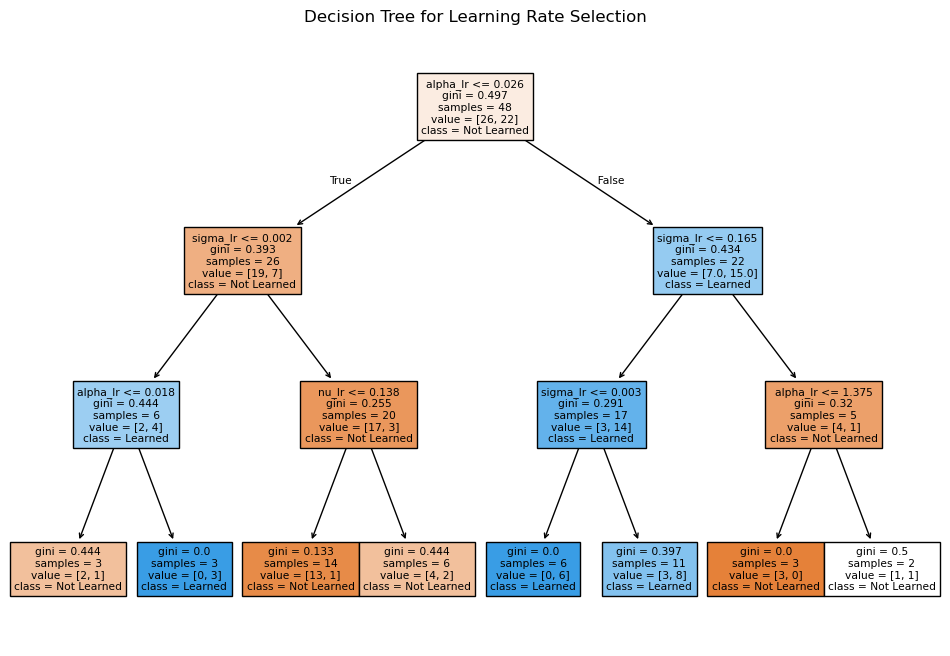

Feature Importances: [0.47495875 0.04568389 0.47935737]


In [9]:
# Decision Tree for Feature Importance and Thresholds
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Fit decision tree classifier on binary target
tree_clf = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_clf.fit(X, y_binary)

# Plot the decision tree
plt.figure(figsize=(12, 8))
plot_tree(tree_clf, feature_names=['alpha_lr', 'nu_lr', 'sigma_lr'], class_names=['Not Learned', 'Learned'], filled=True)
plt.title("Decision Tree for Learning Rate Selection")
plt.show()

# Feature importances
print("Feature Importances:", tree_clf.feature_importances_)


Coefficients: [229.18742504 -17.83147256 114.39424919]
Intercept: -10.857171565100458


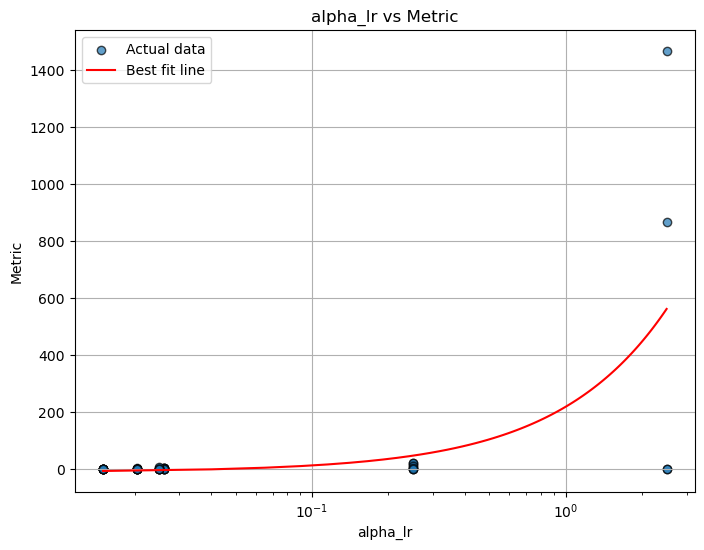

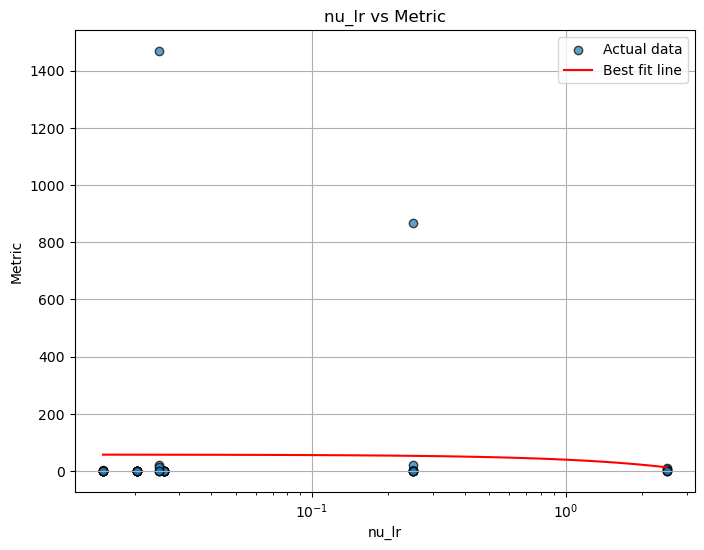

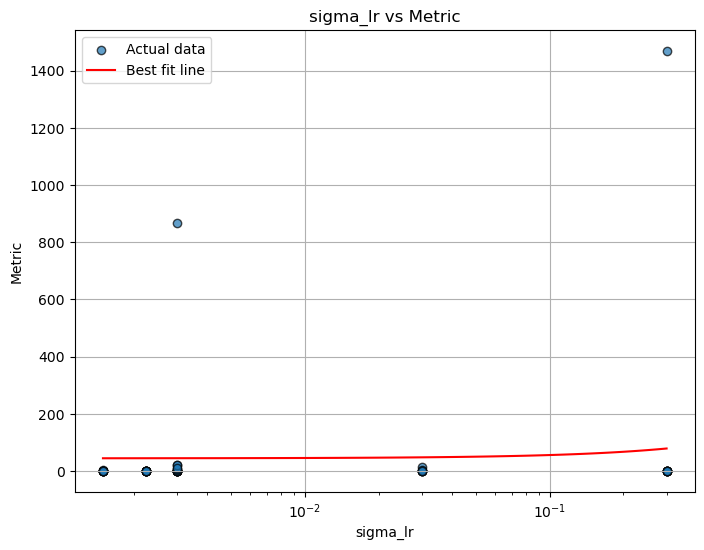

In [10]:
## linear regression

model = LinearRegression()
model.fit(X, y)

# Display the model's coefficients and intercept
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

# Calculate mean values of features for use in predictions
alpha_mean = X['alpha_lr'].mean()
nu_mean = X['nu_lr'].mean()
sigma_mean = X['sigma_lr'].mean()

# Generate predictions for each feature against the target
features = ['alpha_lr', 'nu_lr', 'sigma_lr']
for feature in features:
    # Prepare feature values for plotting
    x_vals = np.linspace(X[feature].min(), X[feature].max(), 100)
    
    # Create a DataFrame with mean values and vary the selected feature
    X_plot = pd.DataFrame({
        'alpha_lr': [alpha_mean] * 100,
        'nu_lr': [nu_mean] * 100,
        'sigma_lr': [sigma_mean] * 100,
    })
    X_plot[feature] = x_vals  # vary only the selected feature

    # Predict the metric using the model
    y_pred = model.predict(X_plot)

    # Plot the data points and the best-fit line
    plt.figure(figsize=(8, 6))
    plt.scatter(X[feature], y, alpha=0.7, edgecolor='k', label="Actual data")
    plt.plot(x_vals, y_pred, color='red', label="Best fit line")
    plt.title(f'{feature} vs Metric')
    plt.xlabel(feature)
    plt.ylabel('Metric')
    plt.xscale("log")
    plt.legend()
    plt.grid(True)
    plt.show()

In [11]:
## linear regression after rewriting the responses into binary labels (0 for small error and 1 for large error)

Coefficients: [ 0.13225648  0.07378045 -1.77157998]
Intercept: 0.4941441915136389


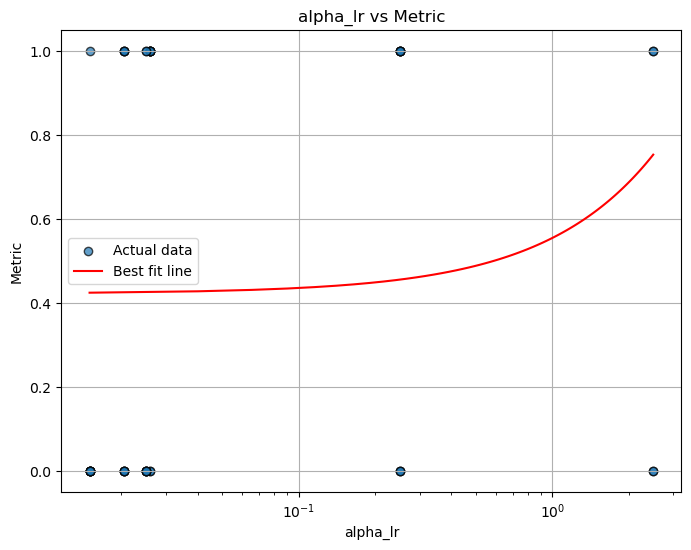

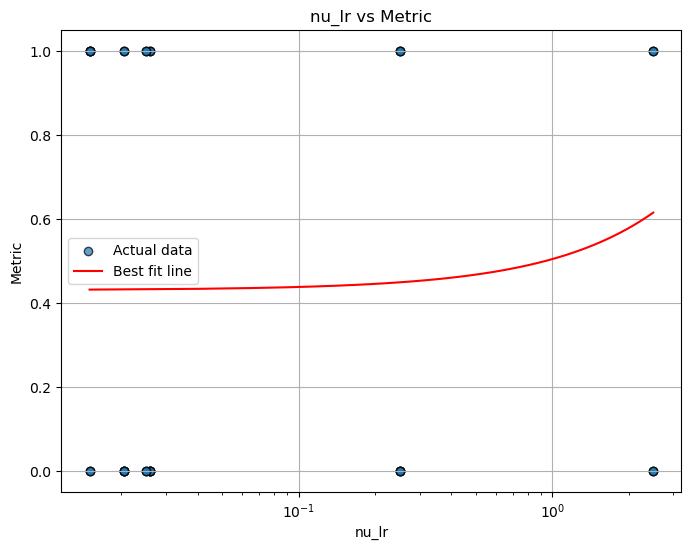

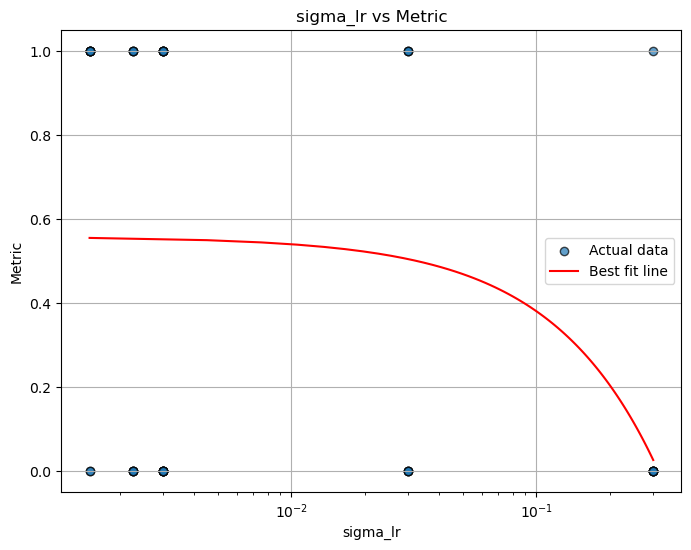

In [12]:
response_df = response_df.apply(lambda x: 0 if x < 0.75 else 1)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

data_df = pd.concat([features_df, response_df.rename("metric")], axis=1)

# Fit linear regression model
X = data_df[['alpha_lr', 'nu_lr', 'sigma_lr']]
y = data_df['metric']

model = LinearRegression()
model.fit(X, y)

# Display the model's coefficients and intercept
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

# Calculate mean values of features for use in predictions
alpha_mean = X['alpha_lr'].mean()
nu_mean = X['nu_lr'].mean()
sigma_mean = X['sigma_lr'].mean()

# Generate predictions for each feature against the target
features = ['alpha_lr', 'nu_lr', 'sigma_lr']
for feature in features:
    # Prepare feature values for plotting
    x_vals = np.linspace(X[feature].min(), X[feature].max(), 100)
    
    # Create a DataFrame with mean values and vary the selected feature
    X_plot = pd.DataFrame({
        'alpha_lr': [alpha_mean] * 100,
        'nu_lr': [nu_mean] * 100,
        'sigma_lr': [sigma_mean] * 100,
    })
    X_plot[feature] = x_vals  # vary only the selected feature

    # Predict the metric using the model
    y_pred = model.predict(X_plot)

    # Plot the data points and the best-fit line
    plt.figure(figsize=(8, 6))
    plt.scatter(X[feature], y, alpha=0.7, edgecolor='k', label="Actual data")
    plt.plot(x_vals, y_pred, color='red', label="Best fit line")
    plt.title(f'{feature} vs Metric')
    plt.xlabel(feature)
    plt.ylabel('Metric')
    plt.legend()
    plt.xscale("log")
    plt.grid(True)
    plt.show()